Libraries loaded successfully.
Youth Unemployment shape: (17290, 4)
Employment/GDP shape    : (5751, 7)
Youth rows after cleaning: 7519
Unique countries: 235
Countries after merge: 182
Rows after merge     : 5719
Feature engineering done.


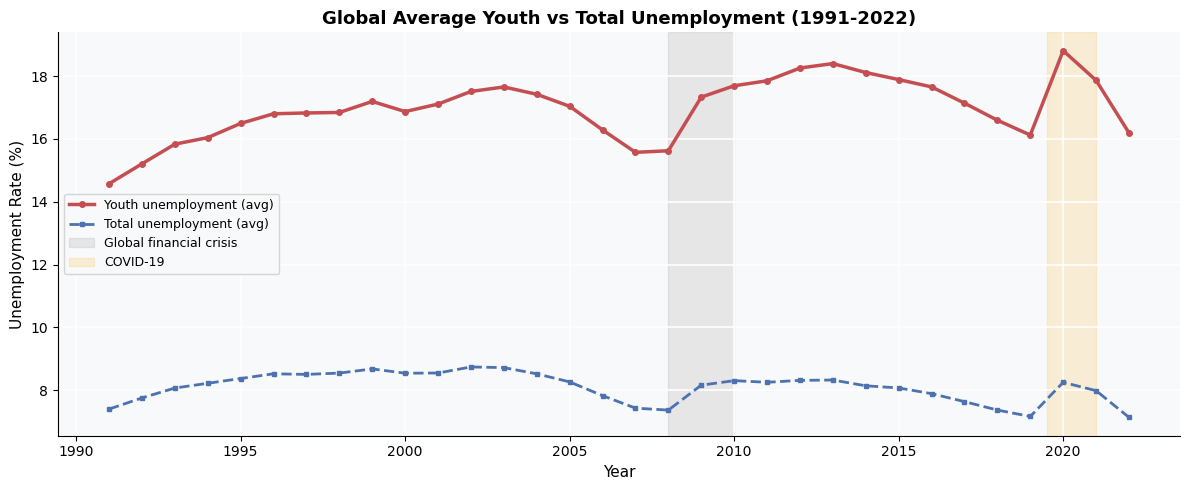

Figure 1 saved.


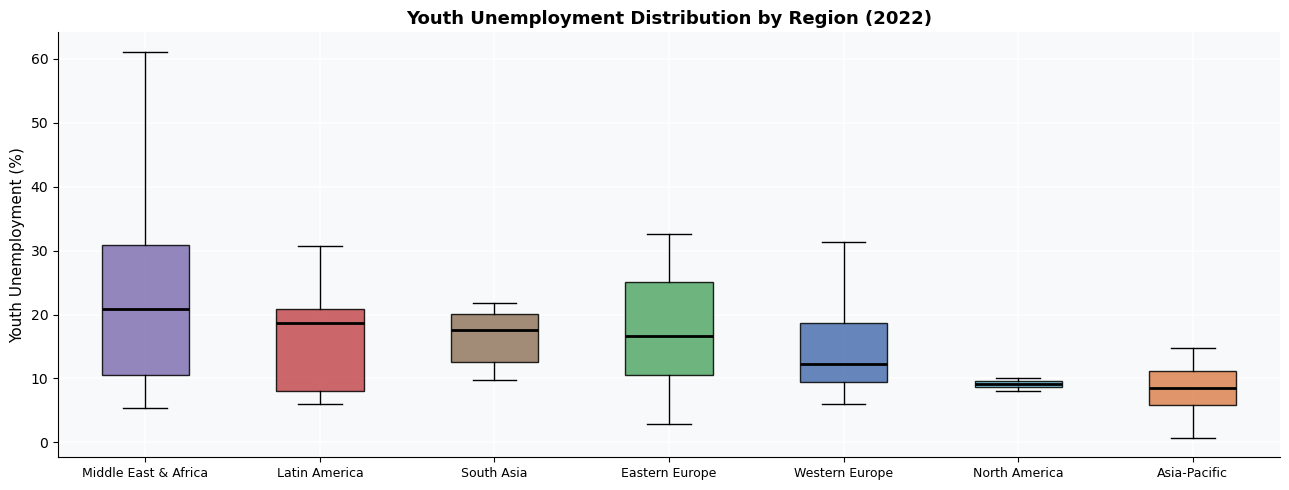

Figure 2 saved.


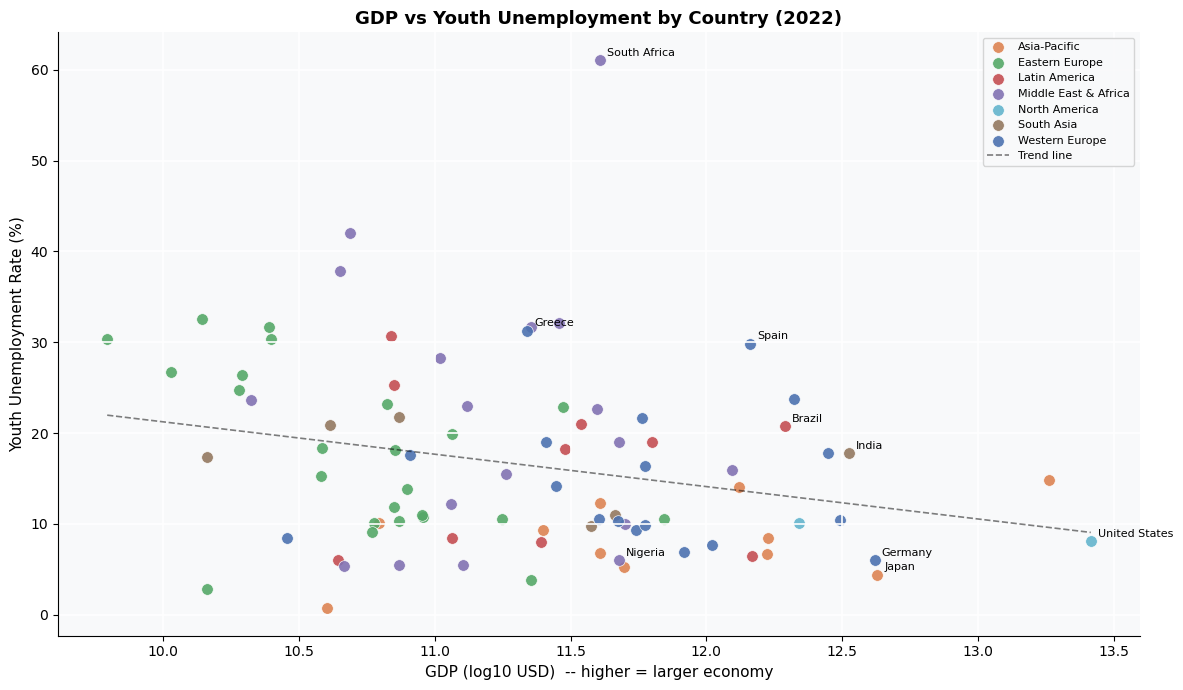

Figure 3 saved.


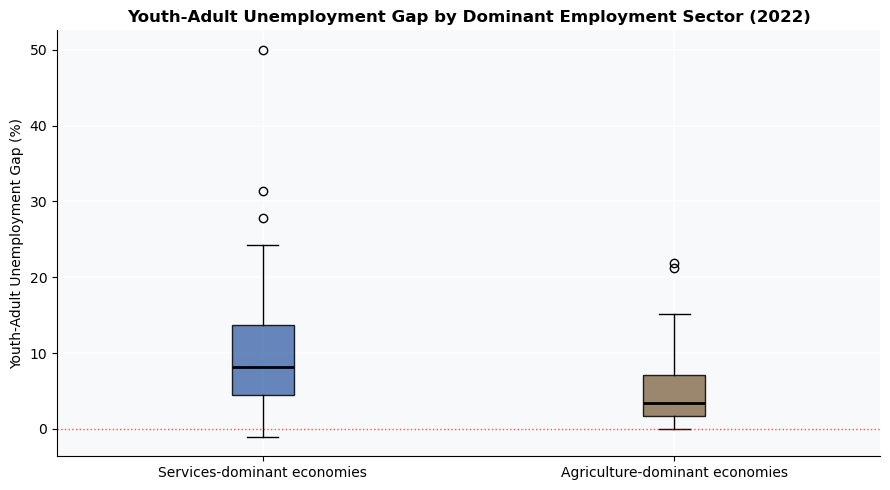

Figure 4 saved.
KEY FINDINGS
1. Global avg youth unemployment peaked at 18.8% in 2020
   and stood at 16.2% in 2022.

2. Highest region (2022): Middle East & Africa (20.9%)
   Lowest  region (2022): Asia-Pacific (8.5%)

3. Top 5 highest youth unemployment countries in 2022:
   South Africa                   61.1%
   Jordan                         42.0%
   Tunisia                        37.8%
   North Macedonia                32.6%
   Iraq                           32.1%

4. Correlation (log GDP vs Youth Unemployment): r = -0.26

5. Median Youth-Adult gap by dominant sector:
   Services        8.2%
   Agriculture     3.4%
Clean dataset saved.
Shape: (5719, 11)


In [1]:
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn numpy

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.grid": True,
    "grid.color": "white",
    "grid.linewidth": 1.2,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

os.makedirs("figures", exist_ok=True)
print("Libraries loaded successfully.")

# ── CELL 2: Load Data ──────────────────────────────────────────────────────
youth_raw = pd.read_csv("youth_unemployment_global.csv")
gdp_raw   = pd.read_csv("Employment_Unemployment_GDP_data.csv")

print("Youth Unemployment shape:", youth_raw.shape)
print("Employment/GDP shape    :", gdp_raw.shape)

# ── CELL 3: Clean & Merge ─────────────────────────────────────────────────
youth = youth_raw.dropna(subset=["YouthUnemployment"])
youth = youth[youth["Year"].between(1991, 2022)]

print("Youth rows after cleaning:", len(youth))
print("Unique countries:", youth["Country"].nunique())

gdp = gdp_raw.copy()

df = youth.merge(
    gdp,
    left_on=["Country", "Year"],
    right_on=["Country Name", "Year"],
    how="inner"
)
print("Countries after merge:", df["Country"].nunique())
print("Rows after merge     :", len(df))

# ── Feature Engineering ───────────────────────────────────────────────────
df["GDP_bn"]    = df["GDP (in USD)"] / 1e9
df["GDP_log"]   = np.log10(df["GDP (in USD)"])
df["Youth_Gap"] = df["YouthUnemployment"] - df["Unemployment Rate"]

df["Dom_Sector"] = (
    df[["Employment Sector: Agriculture",
        "Employment Sector: Industry",
        "Employment Sector: Services"]]
    .idxmax(axis=1)
    .str.replace("Employment Sector: ", "", regex=False)
)

region_map = {
    "Afghanistan":"South Asia","Bangladesh":"South Asia","India":"South Asia",
    "Nepal":"South Asia","Pakistan":"South Asia","Sri Lanka":"South Asia",
    "Albania":"Eastern Europe","Armenia":"Eastern Europe","Azerbaijan":"Eastern Europe",
    "Belarus":"Eastern Europe","Bosnia and Herzegovina":"Eastern Europe",
    "Bulgaria":"Eastern Europe","Croatia":"Eastern Europe","Czech Republic":"Eastern Europe",
    "Estonia":"Eastern Europe","Georgia":"Eastern Europe","Hungary":"Eastern Europe",
    "Kazakhstan":"Eastern Europe","Kosovo":"Eastern Europe","Latvia":"Eastern Europe",
    "Lithuania":"Eastern Europe","Moldova":"Eastern Europe","Montenegro":"Eastern Europe",
    "North Macedonia":"Eastern Europe","Poland":"Eastern Europe","Romania":"Eastern Europe",
    "Russia":"Eastern Europe","Serbia":"Eastern Europe","Slovak Republic":"Eastern Europe",
    "Slovenia":"Eastern Europe","Tajikistan":"Eastern Europe","Turkey":"Eastern Europe",
    "Turkmenistan":"Eastern Europe","Ukraine":"Eastern Europe","Uzbekistan":"Eastern Europe",
    "Australia":"Asia-Pacific","China":"Asia-Pacific","Indonesia":"Asia-Pacific",
    "Japan":"Asia-Pacific","Korea, Rep.":"Asia-Pacific","Malaysia":"Asia-Pacific",
    "Myanmar":"Asia-Pacific","New Zealand":"Asia-Pacific","Philippines":"Asia-Pacific",
    "Thailand":"Asia-Pacific","Vietnam":"Asia-Pacific","Cambodia":"Asia-Pacific",
    "Austria":"Western Europe","Belgium":"Western Europe","Denmark":"Western Europe",
    "Finland":"Western Europe","France":"Western Europe","Germany":"Western Europe",
    "Greece":"Western Europe","Iceland":"Western Europe","Ireland":"Western Europe",
    "Italy":"Western Europe","Luxembourg":"Western Europe","Netherlands":"Western Europe",
    "Norway":"Western Europe","Portugal":"Western Europe","Spain":"Western Europe",
    "Sweden":"Western Europe","Switzerland":"Western Europe","United Kingdom":"Western Europe",
    "Algeria":"Middle East & Africa","Angola":"Middle East & Africa",
    "Bahrain":"Middle East & Africa","Egypt, Arab Rep.":"Middle East & Africa",
    "Ethiopia":"Middle East & Africa","Ghana":"Middle East & Africa",
    "Iran, Islamic Rep.":"Middle East & Africa","Iraq":"Middle East & Africa",
    "Jordan":"Middle East & Africa","Kenya":"Middle East & Africa",
    "Kuwait":"Middle East & Africa","Lebanon":"Middle East & Africa",
    "Morocco":"Middle East & Africa","Nigeria":"Middle East & Africa",
    "Saudi Arabia":"Middle East & Africa","South Africa":"Middle East & Africa",
    "Tunisia":"Middle East & Africa","United Arab Emirates":"Middle East & Africa",
    "Yemen, Rep.":"Middle East & Africa",
    "Argentina":"Latin America","Bolivia":"Latin America","Brazil":"Latin America",
    "Chile":"Latin America","Colombia":"Latin America","Costa Rica":"Latin America",
    "Ecuador":"Latin America","Mexico":"Latin America","Peru":"Latin America",
    "Uruguay":"Latin America","Venezuela, RB":"Latin America",
    "Canada":"North America","United States":"North America",
}
df["Region"] = df["Country"].map(region_map).fillna("Other")
df = df.sort_values(["Country","Year"]).reset_index(drop=True)
print("Feature engineering done.")

# ── CELL 4: Figure 1 — Global Trend ───────────────────────────────────────
trend = (
    df.groupby("Year")["YouthUnemployment"]
    .mean().reset_index()
    .rename(columns={"YouthUnemployment": "AvgYouth"})
)
trend_all = (
    df.groupby("Year")["Unemployment Rate"]
    .mean().reset_index()
    .rename(columns={"Unemployment Rate": "AvgAll"})
)
trend = trend.merge(trend_all, on="Year")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(trend["Year"], trend["AvgYouth"], color="#C44E52", linewidth=2.5,
        marker="o", markersize=4, label="Youth unemployment (avg)")
ax.plot(trend["Year"], trend["AvgAll"], color="#4C72B0", linewidth=2,
        linestyle="--", marker="s", markersize=3, label="Total unemployment (avg)")
ax.axvspan(2008, 2010, alpha=0.15, color="grey", label="Global financial crisis")
ax.axvspan(2019.5, 2021, alpha=0.15, color="orange", label="COVID-19")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Unemployment Rate (%)", fontsize=11)
ax.set_title("Global Average Youth vs Total Unemployment (1991-2022)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figures/fig1_global_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved.")

# ── CELL 5: Figure 2 — Regional Boxplot ───────────────────────────────────
REGION_COLOURS = {
    "Western Europe":       "#4C72B0",
    "Eastern Europe":       "#55A868",
    "Latin America":        "#C44E52",
    "Asia-Pacific":         "#DD8452",
    "Middle East & Africa": "#8172B2",
    "South Asia":           "#937860",
    "North America":        "#64B5CD",
    "Other":                "#AAAAAA",
}

latest = df[df["Year"] == 2022].copy()
latest_filtered = latest[latest["Region"] != "Other"]

region_order = (
    latest_filtered.groupby("Region")["YouthUnemployment"]
    .median().sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(13, 5))
box_data = [
    latest_filtered[latest_filtered["Region"] == r]["YouthUnemployment"].values
    for r in region_order
]
bp = ax.boxplot(box_data, patch_artist=True, vert=True,
                medianprops=dict(color="black", linewidth=2))
for patch, region in zip(bp["boxes"], region_order):
    patch.set_facecolor(REGION_COLOURS.get(region, "#AAAAAA"))
    patch.set_alpha(0.85)
ax.set_xticks(range(1, len(region_order)+1))
ax.set_xticklabels(region_order, fontsize=9)
ax.set_ylabel("Youth Unemployment (%)", fontsize=11)
ax.set_title("Youth Unemployment Distribution by Region (2022)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig2_regional_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2 saved.")

# ── CELL 6: Figure 3 — GDP vs Youth Unemployment ──────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
for region, grp in latest_filtered.groupby("Region"):
    ax.scatter(grp["GDP_log"], grp["YouthUnemployment"],
               label=region,
               color=REGION_COLOURS.get(region, "#AAAAAA"),
               s=70, edgecolors="white", linewidth=0.5, alpha=0.9)

highlight = ["South Africa","Greece","Spain","United States","Japan",
             "Germany","Brazil","Turkey","India","Nigeria"]
for _, row in latest_filtered[latest_filtered["Country"].isin(highlight)].iterrows():
    ax.annotate(row["Country"],
                xy=(row["GDP_log"], row["YouthUnemployment"]),
                xytext=(5, 3), textcoords="offset points", fontsize=8)

slope, intercept = np.polyfit(latest_filtered["GDP_log"],
                               latest_filtered["YouthUnemployment"], 1)
x_line = np.linspace(latest_filtered["GDP_log"].min(),
                      latest_filtered["GDP_log"].max(), 100)
ax.plot(x_line, slope*x_line + intercept, "k--", linewidth=1.2,
        alpha=0.5, label="Trend line")

ax.set_xlabel("GDP (log10 USD)  -- higher = larger economy", fontsize=11)
ax.set_ylabel("Youth Unemployment Rate (%)", fontsize=11)
ax.set_title("GDP vs Youth Unemployment by Country (2022)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig("figures/fig3_gdp_vs_youth.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 3 saved.")

# ── CELL 7: Figure 4 — Youth Gap by Sector ────────────────────────────────
sector_latest = latest[latest["Dom_Sector"].isin(["Agriculture","Services","Industry"])].copy()
sector_order = (
    sector_latest.groupby("Dom_Sector")["Youth_Gap"]
    .median().sort_values(ascending=False).index.tolist()
)
SECTOR_COLOURS = {
    "Agriculture": "#8B7355",
    "Services":    "#4C72B0",
    "Industry":    "#DD8452",
}
fig, ax = plt.subplots(figsize=(9, 5))
box_data2 = [
    sector_latest[sector_latest["Dom_Sector"] == s]["Youth_Gap"].values
    for s in sector_order
]
bp2 = ax.boxplot(box_data2, patch_artist=True, vert=True,
                  medianprops=dict(color="black", linewidth=2))
for patch, sec in zip(bp2["boxes"], sector_order):
    patch.set_facecolor(SECTOR_COLOURS.get(sec, "#AAAAAA"))
    patch.set_alpha(0.85)
ax.set_xticks(range(1, len(sector_order)+1))
ax.set_xticklabels([f"{s}-dominant economies" for s in sector_order], fontsize=10)
ax.set_ylabel("Youth-Adult Unemployment Gap (%)", fontsize=10)
ax.set_title("Youth-Adult Unemployment Gap by Dominant Employment Sector (2022)",
             fontsize=12, fontweight="bold")
ax.axhline(0, color="red", linestyle=":", linewidth=1, alpha=0.7)
plt.tight_layout()
plt.savefig("figures/fig4_gap_by_sector.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 4 saved.")

# ── CELL 8: Key Findings ──────────────────────────────────────────────────
sep = "=" * 60
print(sep)
print("KEY FINDINGS")
print(sep)

peak_year = trend.loc[trend["AvgYouth"].idxmax(), "Year"]
peak_val  = round(trend["AvgYouth"].max(), 1)
latest_val = round(trend.loc[trend["Year"]==2022, "AvgYouth"].values[0], 1)
print(f"1. Global avg youth unemployment peaked at {peak_val}% in {peak_year}")
print(f"   and stood at {latest_val}% in 2022.")

region_med = latest_filtered.groupby("Region")["YouthUnemployment"].median().sort_values(ascending=False)
print(f"\n2. Highest region (2022): {region_med.index[0]} ({round(region_med.iloc[0],1)}%)")
print(f"   Lowest  region (2022): {region_med.index[-1]} ({round(region_med.iloc[-1],1)}%)")

top5 = latest_filtered.nlargest(5,"YouthUnemployment")[["Country","YouthUnemployment"]]
print("\n3. Top 5 highest youth unemployment countries in 2022:")
for _, row in top5.iterrows():
    print(f"   {row['Country']:<30} {round(row['YouthUnemployment'],1)}%")

r = latest_filtered["GDP_log"].corr(latest_filtered["YouthUnemployment"])
print(f"\n4. Correlation (log GDP vs Youth Unemployment): r = {round(r,2)}")

gap_by_sector = sector_latest.groupby("Dom_Sector")["Youth_Gap"].median().sort_values(ascending=False)
print("\n5. Median Youth-Adult gap by dominant sector:")
for sec, val in gap_by_sector.items():
    print(f"   {sec:<15} {round(val,1)}%")
print(sep)

# ── CELL 9: Export ────────────────────────────────────────────────────────
import os
os.makedirs("data", exist_ok=True)  # ✅ create folder if missing

output_cols = [
    "Country","Region","Year",
    "YouthUnemployment","Unemployment Rate","Youth_Gap",
    "Employment Sector: Agriculture","Employment Sector: Industry",
    "Employment Sector: Services","Dom_Sector","GDP_bn"
]

df[output_cols].to_csv("data/merged_youth_unemployment_clean.csv", index=False)

print("Clean dataset saved.")
print("Shape:", df[output_cols].shape)